In [ ]:
##############################################################################
# AI & OPTIMIZATION - LAB 01 - 2025/2026
##############################################################################

In [1]:
# System imports
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import datetime
from time import process_time

# Extra library imports
from PIL import Image
from scipy.optimize import minimize
import scipy.ndimage as ndi
import pandas as pd

In [2]:
# User inputs
impath = 'im.png'
labelspath = 'labels.csv'
datadir = './data'

In image processing, a bounding box is a rectangle that fully encloses an object. This representation is very useful to visualize the result of a detection algorithm, for example to track cars on real-time highways' videos. Usually, the area of the bounding box is as small as possible, and its axes are aligned with those of the image coordinate system. In this lab, we will improve this classical representation by searching the bounding box of smallest area having any possible orientation... and so, by solving an optimization problem!

# I. Search of the optimal bounding box

## a) A very short tutorial on image processing

In this lab, we will try our method on a ladybug image (because it is cute, and a lucky charm)!
But first, we have to understand some basic concepts in image processing.
We start by loading a ladybug image, and then we convert it into an array.

In [3]:
# Load the input image
im_arr = np.array(Image.open(impath))
sx, sy, nb_channels = im_arr.shape
print('Input image of dimension {0} x {1} x {2} pixels'.format(sx, sy,
                                                               nb_channels))
print('Input image of type {0}'.format(type(im_arr[0, 0, 0])))
print('Minimal intensity value: {0}'.format(np.min(im_arr)))
print('Maximal intensity value: {0}'.format(np.max(im_arr)))

Input image of dimension 683 x 1024 x 3 pixels
Input image of type <class 'numpy.uint8'>
Minimal intensity value: 0
Maximal intensity value: 255


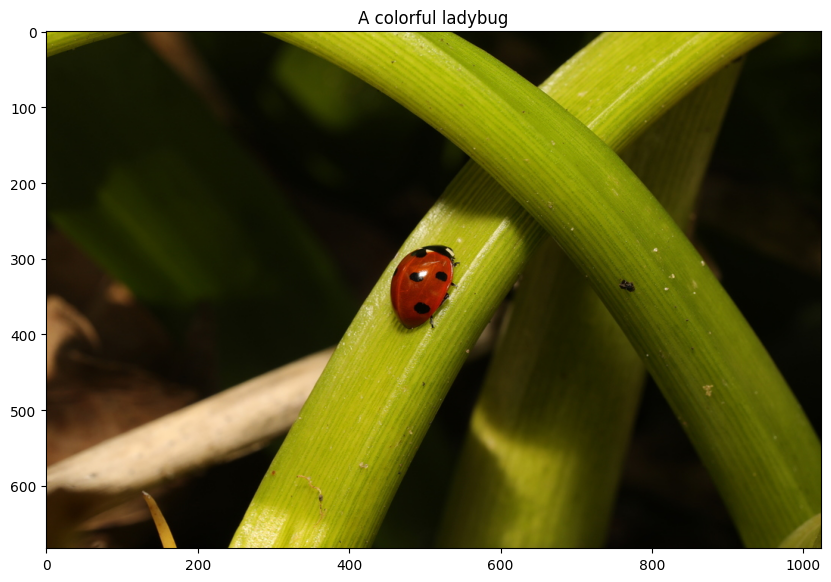

In [4]:
# Display the loaded image
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im_arr)
ax.set_title('A colorful ladybug');

We loaded an image of size 683 x 1024 x 3 pixels: the displayed image is a RGB image, namely a superimposing of the Red, Green and Blue channels (in this order).
For each point of the image, called a pixel, each channel contains information about its amount of red, green and blue. This information is encoded in the gray levels, also called intensity values, ranging here from 0 to 255.
We can also visualize each distinct channel.

Dimension of the Red channel image: (683, 1024)
Dimension of the Green channel image: (683, 1024)
Dimension of the Blue channel image: (683, 1024)


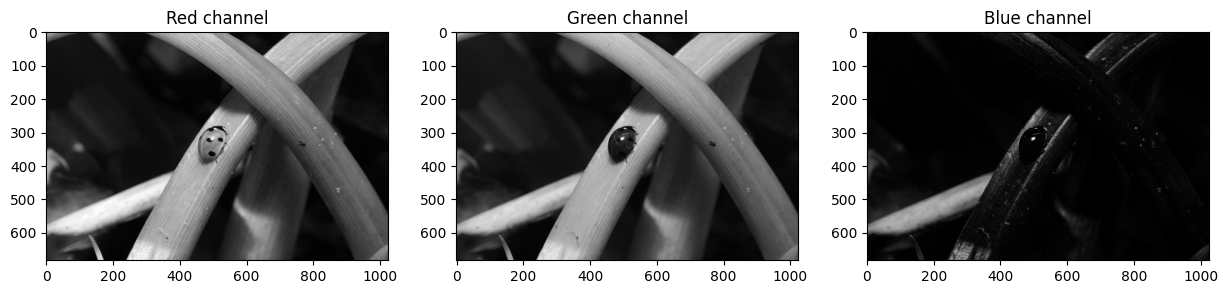

In [5]:
# Display each channel
fig, ax = plt.subplots(1, 3, figsize=(15, 15))
for channel_id, channel_color in enumerate(['Red', 'Green', 'Blue']):
    ax[channel_id].imshow(im_arr[:, :, channel_id],
                          cmap='gray')
    ax[channel_id].set_title('{0} channel'.format(channel_color))
    print('Dimension of the {0} channel image: {1}'.format(channel_color,
    im_arr[:, :, channel_id].shape))

Thus, each displayed channel is a grey-level image of dimension 683 x 1024 pixels.
Our ladybug is mostly made of red: it is relatively bright on the red channel (high intensity values), while it appears very dark on the green and blue channels (low intensity values).

To go further, we now want to detect the contours of the ladybug. This task, called segmentation, seems pretty easy here, because of the high difference in intensity values between the foreground (the almost red ladybug) and the background (the green plant)!

Following this intuition, we will now focus on the green channel of the input image.

In [7]:
# Extract the green channel
glim_arr = im_arr[:, :, 1]
print('Image dimension after transformation : {0}'.format(glim_arr.shape))

Image dimension after transformation : (683, 1024)


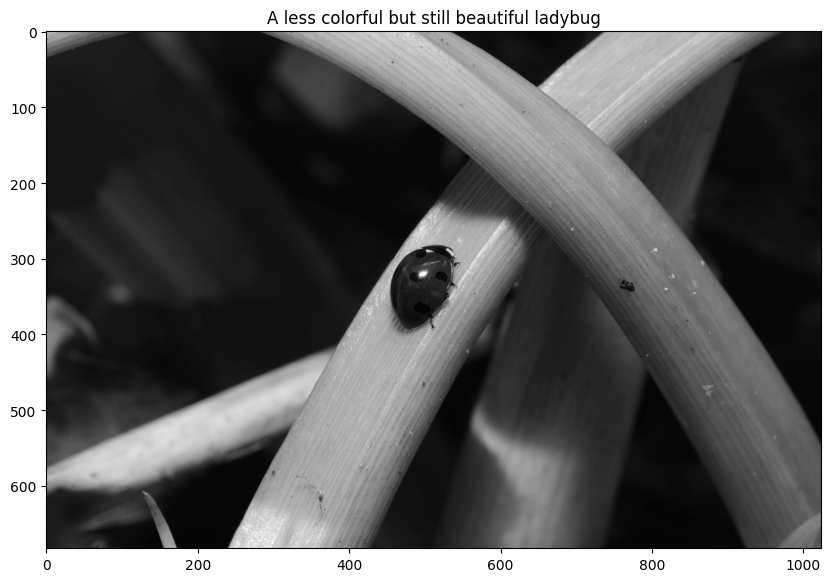

In [8]:
# Display the green channel image
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(glim_arr, cmap='gray')
ax.set_title('A less colorful but still beautiful ladybug');

A very simple, but not always working, way to segment an object on a grey-level image is to threshold its intensity values to a fixed threshold value. We obtain here a pretty nice result taking the half of the maximum intensity value as a threshold.

In [9]:
# Binary segmentation of the ladybug by thresholding
mask_arr = (glim_arr <= 0.5 * np.max(glim_arr)).astype(int)

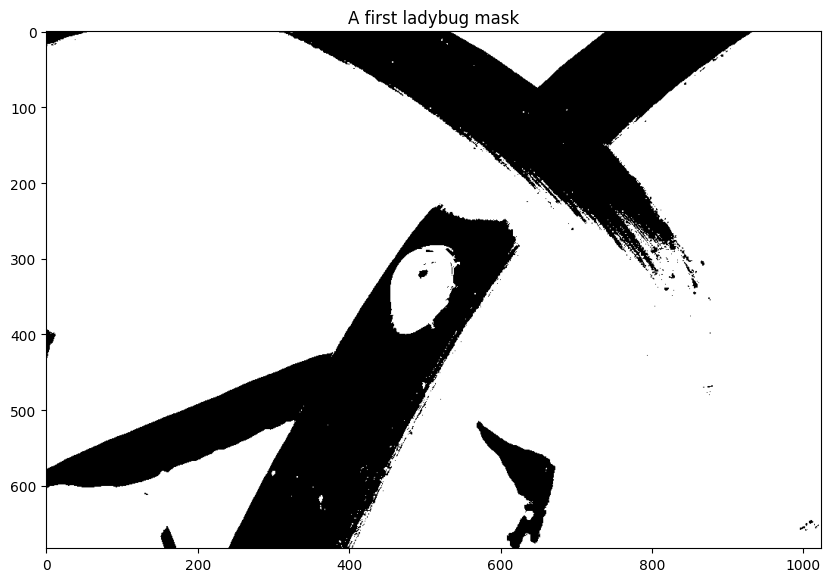

In [10]:
# Display the obtained mask
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask_arr, cmap='gray')
ax.set_title('A first ladybug mask');

Thus, we obtained a binary image, namely an image with two possible intensity values: 1 for the foreground and 0 for the background. The dimension of the mask array is the same as the green channel of the input image.

To clean this segmentation, we will first fill the "holes" in this binary image. To simplify, we will use the function *binary_fill_holes* implemented in Scipy's library.

In [ ]:
# Hole filling on the input binary image
mask_arr = ndi.binary_fill_holes(mask_arr).astype(int)

# Display the filled mask
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask_arr, cmap='gray')
ax.set_title('The filled ladybug mask');

However, this binary image is not exactly a mask of the ladybug: we want to remove the regions associated with the background.
To that purpose, we first compute the regions composing the binary image, formally called the connected components.

322 connected components in the input binary image


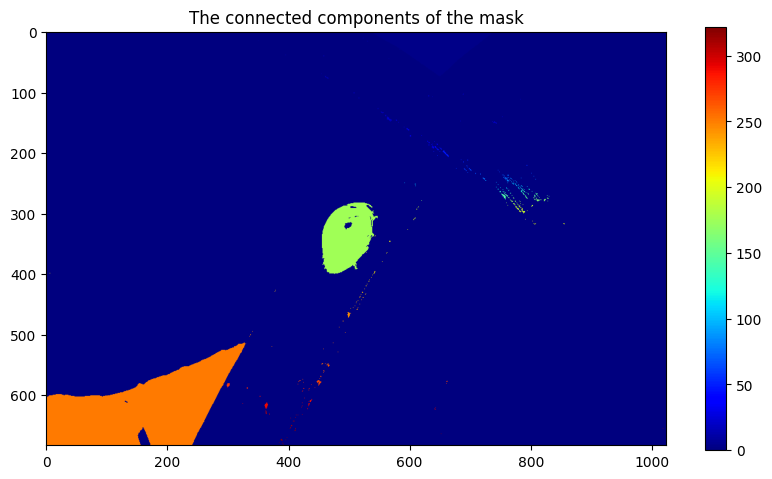

In [11]:
# Compute the connected components (i.e regions) of the binary image
ccs_arr, nb_ccs = ndi.label(mask_arr)
print('{0} connected components in the input binary image'.format(nb_ccs))

# Display the connected components
fig, ax = plt.subplots(figsize=(10, 10))
im0 = ax.imshow(ccs_arr, cmap='jet', vmin=0, vmax = nb_ccs)
cb = plt.colorbar(im0, shrink=0.55)
ax.set_title('The connected components of the mask');

Thus, each connected component is associated with a label of value greater than 0. The 0 value is associated with the background of the input binary image (i.e. with 0 value).
We want to only select the appropriate connected component. To properly perform this step, we could perform machine learning to select the region with the desired properties (shape, area, etc.).

To simplify, we will follow this assumption: the ladybug is associated with the connected component of highest area not touching the border of the image.

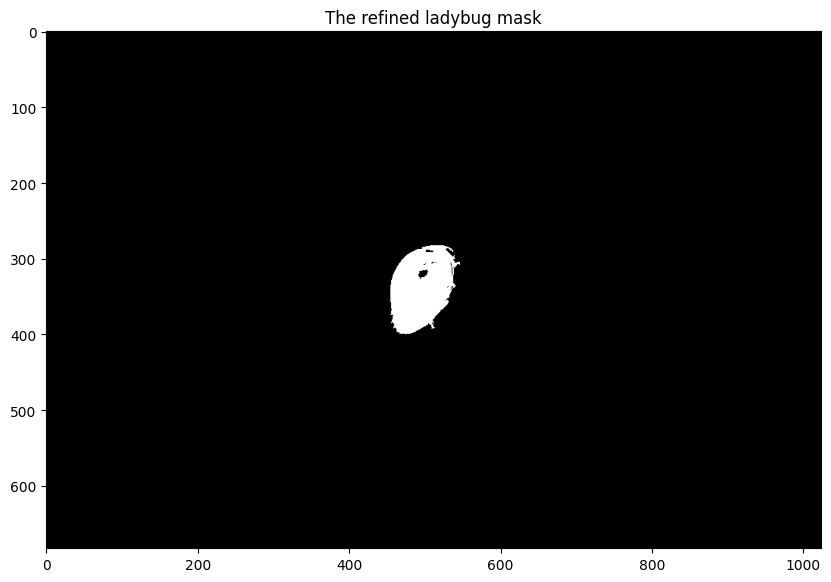

In [12]:
# Compute the areas of each connected component (i.e. with label > 0)
cc_ids, cc_areas = np.unique(ccs_arr[ccs_arr > 0], return_counts=True)

# Sort the cc indexes by increasing order of area
sort_ids = np.argsort(cc_areas)

# Sort the cc indexes by decreasing order of area
sort_ids = sort_ids[::-1]

# Get the 3rd connected component of highest area
bug_cc_id = cc_ids[sort_ids[2]]

# Select the cc
mask_arr = (ccs_arr == bug_cc_id).astype(int)

# Display the mask
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask_arr, cmap='gray')
ax.set_title('The refined ladybug mask');

The result is quite good! However, there are "holes" in the mask of the ladybug. For further process, we need to fill these holes. To simplify, we will use the function *binary_fill_holes* implemented in Scipy's library.

In [ ]:
# Hole filling on the input binary image
mask_arr = ndi.binary_fill_holes(mask_arr).astype(int)

# Display the filled mask
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask_arr, cmap='gray')
ax.set_title('The filled ladybug mask');

To check our segmentation, we can superimpose the original image and the contours of the obtained mask.

In [ ]:
# Display the contours of the segmentation
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im_arr)
ax.contour(mask_arr, [0.5], colors = 'b');
ax.set_title('Final contours of the ladybug');

The segmentation of the ladybug is quite well. Obviously, it could be improved... but this is out of this topic!

We could now extract features from this segmentation, for example related to shape or color intensity.
For some shape characteristics, for example diameter or perimeter, we need to extract the pixels belonging to the segmentation. We can use the *where* function of Numpy for that purpose.

In [ ]:
# Get the coordinates of the mask pixels
[x, y] =  np.where(mask_arr)
print('The ladybug mask is composed of {0} pixels'.format(len(x)))

One simple feature to get from these coordinates is the centroid: we just have to compute the mean of the detected coordinates.

In [ ]:
# Compute the centroid of the mask
x0 = np.mean(x)
y0 = np.mean(y)

# Display the centroid and the contours of the mask 
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im_arr)
ax.contour(mask_arr, [0.5], colors = 'b', linewidths = [2, 2])
ax.plot(y0, x0, 'bo')
ax.set_title('Centroid and contours of the ladybug');

This figure illustrates a very tricky property: the axes of the displayed image are not the ones of the Cartesian space!
In the image domain, the "y" axis is from left to right, and the "x" axis is from top to down. Thus, if you invert x0 and y0 in the plot command, the centroid may be totally out of the mask (you can try)!

## b) The bounding box of the ladybug

Now we know some basics to process images, we are can compute a very useful property: the bounding box of a binary image.
We will compute the classical bounding box, namely the rectangle that fully encloses an object, with area as small as possible and axes oriented with those of the image coordinate system.
In fact, it can be simply computed using the coordinates of the pixels composing the object of interest!

In [ ]:
# Compute the bounding box of the mask
bb_arr = np.zeros((sx, sy)).astype(int)
bb_arr[np.min(x):np.max(x) + 1, np.min(y):np.max(y) + 1] = 1

In [ ]:
# Display the mask and coordinates used to create the bounding box
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask_arr, cmap='gray')
ax.plot(range(sy), [np.min(x)] * sy, '--c', label='min(x)')
ax.plot(range(sy), [np.max(x)] * sy, '--b', label='max(x)')
ax.plot([np.min(y)] * sx, range(sx), '--m', label='min(y)')
ax.plot([np.max(y)] * sx, range(sx), '--r', label='max(y)')
ax.legend()
ax.set_title('Explanation of the bounding box');

In [ ]:
# Display the bounding box of the mask
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(bb_arr, cmap='gray')
ax.set_title('The bounding box of the ladybug');

To check the results visually, we can superimpose the contours of the bounding box on the original image.

In [ ]:
# Display the original image and the contours of the bounding box
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im_arr)
ax.contour(bb_arr, [0.5], colors = 'b')
ax.set_title('A ladybug within a box');

The computed box fully encloses the ladybug! We can also check more quantitatively this fact, by checking that all the ladybug pixels are well included in the bounding box.

<font color='blue'> Question 1: compute and display the percentage of ladybug pixels that are fully included in the bounding box, using the *sum* function of Numpy. </font>

In [ ]:
ratio = # ... to complete ...
print('{0}% of ladybug pixels are in the bounding box'.format(ratio * 100))

Thus, we computed a bounding box that fully encloses the ladybug. This box is also of minimal area: the number of pixels composing it is as small as possible. As a consequence, the space occupied by the ladybug within its bounding box should be as high as possible!

<font color='blue'> Question 2: compute and display the ratio between the area of the ladybug and the area of the bounding box, using the *sum* function of Numpy. </font>

In [ ]:
#..............................Completed part ...............................#
ratio = # ... to complete ...
print('The ladybug fills {0}% of its bounding box'.format(ratio * 100))
#............................................................................#

You should find that the ladybug fills around 70% of its bounding box. That's quite high! In fact, it is possible to increase this ratio by finding a bounding box that best fits the input binary object, considering any possible box orientation... and so, by performing an optimization algorithm!

## c) Computation of the best fitted bounding box

We search for an optimal bounding box having any possible orientation. To simplify, we will divide our method in two steps:
- application of a rotation on the classical bounding box of an input binary image
- computation of the space occupied by the rotated input binary image within this new box

The space occupied by the rotated input binary image within its bounding box should be as high as possible! Moreover, the variables to optimize are the parameters of the rotation, more precisely the angle $\theta$ and the center $(x_c, y_c)$. To simplify, we will assume that the center is fixed, and so restrict our problem to a one dimensional optimization problem.

First, we need to create a function to rotate a binary image.
We recall that the coordinates $(x_r, y_r)$ of a point $(x_i, y_i)$ after rotation of center $(x_c, y_c)$ and angle $\theta$ in an euclidian space is written as:

$
\begin{bmatrix}
x_r \\
y_r 
\end{bmatrix} = 
\begin{bmatrix}
cos(\theta) &  -sin(\theta)\\
sin(\theta) &  cos(\theta)
\end{bmatrix}
\begin{bmatrix}
x_i - x_c\\
y_i - y_c
\end{bmatrix} + \begin{bmatrix}
x_c\\
y_c
\end{bmatrix}
$

<font color='blue'> Question 3: complete the function below to perform a rotation of a binary image. You have to use the *pi*, *cos* and *sin* functions of Numpy. </font>

In [ ]:
def rotate_image_v0(theta_degree, xc, yc, arr):

    """ Rotation of angle theta_degree and center (xc, yx) of a binary image
    arr
        
    Inputs
    ----------
    theta_degree: float
        angle in degree
    xc: float
        x coordinate of the rotation center
    yc: float
        y coordinate of the rotation center
    arr: 2D array of floats
        gray-level 2D image      
        
    Ouputs
    -------
    rot_arr: 2D array
        the output rotated image
        
    Command:
    rot_arr = rotate_image_v0(theta_degree, xc, yc, arr)
    """
        
    # Convert the angle into radian
    theta = # ... to complete ...
    
    # Image size
    s1, s2 = arr.shape
    
    # Get all the pixels in the input array
    [xi, yi] = np.where(arr)
    
    # Compute the coordinate (xr, yr) obtained after rotation
    # in function of (xi, yi), theta and (xc, yc)
    xr = # ... to complete ...
    yr = # ... to complete ...

    # Convert the coordinates into integer
    xr = # ... to complete ...
    yr = # ... to complete ...
    
    # Remove pixels out of the image
    xi = xi[xr < s1]
    yi = yi[xr < s1]
    yr = yr[xr < s1]
    xr = xr[xr < s1]
    
    xi = xi[yr < s2]
    yi = yi[yr < s2]    
    xr = xr[yr < s2]
    yr = yr[yr < s2]
    
    xi = xi[xr >= 0]
    yi = yi[xr >= 0]  
    yr = yr[xr >= 0]
    xr = xr[xr >= 0]

    xi = xi[yr >= 0]
    yi = yi[yr >= 0] 
    xr = xr[yr >= 0]
    yr = yr[yr >= 0]
    
    # Initialize the rotation array (binary image)
    rot_arr = np.zeros((s1, s2))
   
    # Update the rotation array  
    for i in range(len(xr)):
        rot_arr[xr[i], yr[i]] = arr[xi[i], yi[i]]
        
    return rot_arr

We can now check the implementation of the rotation applying the function of the binary image of the ladybug. 

In [ ]:
# Apply a rotation of 45° on the ladybug mask
rot_arr = rotate_image_v0(45, x0, y0, mask_arr)

# Display the results
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rot_arr, cmap='gray')
ax.plot(y0, x0, 'bo')
ax.set_title('Input image rotated around its centroid');

We see that there are holes in the rotated image: some pixels are missing!

Indeed, we assigned to each pixel (x,y) its rotated point (xr, yr), hoping that this point would not be out of the image.
To solve this problem of missing values, we have to consider the inverse problem: check for each pixel of the rotated image if we can find the associated pixel on the input image.

<font color='blue'> Question 4: complete the function below to properly perform a rotation of a binary image. You have to use the *pi* function of Numpy. </font>

In [ ]:
def rotate_image(theta_degree, xc, yc, arr):
    """ Proper rotation of angle theta_degree and center (xc, yx) of a 
    binary image
        
    Inputs
    ----------
    theta_degree: float
        angle in degree
    xc: float
        x coordinate of the rotation center
    yc: float
        y coordinate of the rotation center
    arr: 2D array of floats
        gray-level 2D image      
        
    Ouputs
    -------
    rot_arr: 2D array
        the output rotated image
        
    Command:
    rot_arr = rotate_image(theta_degree, xc, yc, arr)
    """
     # Convert the angle into radian
    theta = theta_degree * np.pi / 180
    
    # Image size
    s1, s2 = arr.shape
    
    # Coordinates of the pixels in the whole image
    y_arr, x_arr = np.meshgrid(range(s2), range(s1))
    xr = x_arr.flatten()
    yr = y_arr.flatten()
    
    # Compute the original coordinates (xi, yi) in function of
    # of theta, (xc, yc), and the coordinates after rotation (xr, yr)
    xi = # ... to complete ...
    yi = # ... to complete ...

    # Convert the coordinates into integer  
    xi = # ... to complete ...
    yi = # ... to complete ...
    
    # remove pixels out of the image
    xr = xr[xi < s1]
    yr = yr[xi < s1]
    yi = yi[xi < s1]
    xi = xi[xi < s1]
    
    xr = xr[yi < s2]
    yr = yr[yi < s2]    
    xi = xi[yi < s2]
    yi = yi[yi < s2]
    
    xr = xr[xi >= 0]
    yr = yr[xi >= 0]  
    yi = yi[xi >= 0]
    xi = xi[xi >= 0]

    xr = xr[yi >= 0]
    yr = yr[yi >= 0] 
    xi = xi[yi >= 0]
    yi = yi[yi >= 0]
    
    
    # Initialize the rotation array
    rot_arr  = np.zeros((s1, s2))
   
    # Update the rotation array  
    for i in range(len(xr)):
        rot_arr[xr[i], yr[i]] = arr[xi[i], yi[i]]
        
    return rot_arr

We can now check our improved implementation.

In [ ]:
# Apply a rotation of 45° on the ladybug mask
rot_arr = rotate_image(45, x0, y0, mask_arr)

# Display the results
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rot_arr, cmap='gray')
ax.plot(y0, x0, 'bo')
ax.set_title('Input image properly rotated around its center');

You should not see holes anymore in the rotated binary image!
We can now use this function to rotate a classical bounding box.
Once the bounding box has been rotated, we then need to compute the space occupied by the rotated input image within the rotated bounding box. This space should be as high as possible. However, optimization methods generally search for the minimum, and not the maximum, of an objective function. Equivalently, we want to minimize the free space remaining in the rotated bounding box. We can now create a loss function to implement this idea. 

<font color='blue'> Question 5: complete the function below to compute the loss to minimize. </font>

In [ ]:
def bb_loss(theta_degree, xc, yc, arr):
    """ Bounding box loss
        
    Inputs
    ----------
    theta_degree: float
        angle in degree
    xc: float
        x coordinate of the rotation center
    yc: float
        y coordinate of the rotation center
    arr: 2D array of floats
        binary 2D image      
        
    Ouputs
    -------
    loss: float
        the loss
        
    Command:
    loss = bb_loss(theta_degree, xc, yc, arr)
    """
        
    # Image size
    s1, s2 = arr.shape

    # Rotate the input binary image with angle theta_degree
    # and center (xc, yc)
    rot_arr = # ... to complete ...

    # Compute the bounding box of the rotated array rot_arr
    bb_rot_arr = # ... to complete ...

    # Compute the loss, namely the free space in bb_rot_arr 
    loss =  # ... to complete ...
    
    return loss

We have now all the needed functions to optimize the bounding box!
However, we first need to initialize the variable to optimize, *i.e* the angle of the rotation. Moreover, the optimization will be particularly sensitive to the initial value we select. Instead of selecting a random value, we will choose a more refined approach.

<font color='blue'> Question 6: 
- Complete the code below to automatically select the angle of rotation minimizing the loss among values between 0° and 180° and proportional to 20°. We choose the binary mask of the ladybug as the input array, and its centroid as the center of rotation. You may also use the *range* function, and the *argmin* function of Numpy.
- Display the best initial loss value and the associated angle. </font> 

In [ ]:
# Initial angle    
w0 = # ... to complete ...  

# Initial loss value
loss0 = # ... to complete ...

# Display the results
print('Initial angle: {0}° (loss = {1})'.format(w0, loss0))  

We can now optimize this angle using an optimization algorithm, for example the Nelder-Mead method.

<font color='blue'>
Question 7: apply the Nelder-Mead method on the binary mask of the ladybug, taking the best previous initialization as the initial angle. You have to use the function *minimize* of SciPy optimize, with the appropriate method. Ensure that you also get  the optimized variable value at each iteration (see the documentation of the *options* argument).
</font> 

In [ ]:
# Optimization process
start_time = process_time()
# ... to complete ...
stop_time = process_time()

optime = str(datetime.timedelta(seconds=stop_time - start_time))
print(res.message)
print('Computation time : {0}'.format(optime))
print('Convergence reached in {0} iterations'.format(res.nit))
print('Final parameters: {0}'.format(res.x))
print('Final loss: {0}'.format(res.fun))

<font color='blue'>
Question 8: display the optimization result (the OptimizeResult object).
    What are the optimized loss value, the optimized angle value, and the number of iterations needed to reach convergence? Compare the optimized with the initial loss value.
</font> 

In [ ]:
# ... to complete ...

<font color='green'>
     
To complete
</font> 

<font color='blue'>
Question 9: display the evolution of the loss over the iterations using the optimized variable value at each iteration.
</font> 

In [ ]:
# Get the vector of iterative losses
it_losses = # ... to complete ...

# Plot the loss evolution at each iteration
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(range(0, len(it_losses)), it_losses)
ax.set_title('Loss evolution on the {0} iterations'.format(# ... to complete ...))
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss');

<font color='blue'>
Question 10: visualize some results filling the code above.
</font> 

In [ ]:
# Get the optimal angle of the rotation
# from the OptimizeResult object
theta_degree = # ... to complete ...

# Rotate the input binary image with the optimal angle 
# and center (x0, y0)
rot_arr = # ... to complete ...

# Compute the classical bounding box of the rotated input
bb_rot_arr = # ... to complete ...

#Compute the optimal bounding box
best_bb_arr = # ... to complete ...

# Compute the percentage of space occupied by the binary input mask within its  
# optimal bounding box
per = # ... to complete ...
print('The ladybug fills {0}% of its optimal bounding box'.format(per))

# Display the results
fig, ax = plt.subplots(1, 3, figsize=(15, 15))
ax[0].imshow(mask_arr, cmap='gray')
ax[0].contour(bb_arr, [0.5], colors = 'r', linewidths = [2, 2])
ax[0].set_title('Ladybug')
ax[1].imshow(rot_arr, cmap='gray')
ax[1].contour(bb_rot_arr, [0.5], colors = 'r', linewidths = [2, 2])
ax[1].set_title('Optimal rotated ladybug and its bounding box')
ax[2].imshow(mask_arr, cmap='gray')
ax[2].contour(best_bb_arr, [0.5], colors = 'r', linewidths = [2, 2])
ax[2].set_title('Ladybug and its optimal bounding box');

To conlude, we can now display the contours of the optimal bounding box on the RGB image.

In [ ]:
# Display the original image and the contours of the bounding box
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im_arr)
ax.contour(best_bb_arr, [0.5], colors = 'b')
ax.set_title('A ladybug within a better fitted box');

# II. Application of the optimal bounding box (bonus)

Computing the best fitted bounding box of a binary image can be useful to precisely detect objects, or to obtain a region of interest of limited area. Morever, it can be used in classification. Thus, relevant features can be extracted from the optimal bounding box, for example: 
- the ratio between the area of the input binary image and the area of its optimal bounding box,
- the ratio between the width and the length of the optimal bounding box.

We will visually check the relevance of these two features (with values in [0, 1]) to classify binary images into ladybugs or firebugs. 
To simplify, you can equivalently use the rotated input image to compute these features.

<font color='blue'>
    
Question 11:  
- compute the two proposed features on all the images in the *data* directory. 
- Load the labels associated to each image in the *data* directory.
- Display the ratio values between the area of the input binary image and the area of its optimal bounding box in function of the ratio values between the width and the length of the optimal bounding box.
- Could these two features be used separately or conjointly to classify ladybug from firebug binary images?    
</font> 

In [ ]:
# ... to complete ...

<font color='green'>
     
To complete
</font> 